In [72]:
!pip3 install pandas numpy matplotlib seaborn openpyxl
!{sys.executable} -m pip install --break-system-packages scipy

Defaulting to user installation because normal site-packages is not writeable


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [47]:
#loading in sheet from kaggle
season_stats = pd.read_excel('Messi_vs_Ronaldo_Stat.xlsx', sheet_name='All Compitition Exclude Country')
season_stats


,Messi Games,Messi Goals,Messi Assists,Year,Ronaldo Assists,Ronaldo Goals,Ronaldo Games
0,32,18,17,2022/2023,4,12,26
1,34,11,14,2021/2022,3,24,39
2,47,38,12,2020/2021,5,36,44
3,44,31,25,2019/2020,5,37,46
4,50,51,19,2018/2019,10,28,43
5,54,45,18,2017/2018,8,44,44
6,52,54,16,2016/2017,11,42,46
7,49,41,23,2015/2016,15,51,48
8,57,58,27,2014/2015,21,61,54
9,46,41,14,2013/2014,14,51,47


In [55]:
#created a copy so as to not affect the original
#Renaming and reshaping columns for messi and ronaldo for concatination into single dataframe

In [48]:
messi = season_stats[['Year', 'Messi Games', 'Messi Goals', 'Messi Assists']].copy()
messi.columns = ['Year', 'Games', 'Goals', 'Assists']
messi['Player'] = 'Messi'

ronaldo = season_stats[['Year', 'Ronaldo Games', 'Ronaldo Goals', 'Ronaldo Assists']].copy()
ronaldo.columns = ['Year', 'Games', 'Goals', 'Assists']
ronaldo['Player'] = 'Ronaldo'

In [54]:
# Concatinating graph to make sure we can see both stats for messi and ronaldo
#only checking for games they have played and checking to make sure it is seasons they have both played in since ronaldo has playedfor two more years
# ordered the values chronologically

In [53]:
long_stats = pd.concat([messi, ronaldo], ignore_index=True)
long_stats = long_stats[long_stats['Games'] > 0].reset_index(drop=True)
long_stats['Season_Start'] = long_stats['Year'].str[:4].astype(int)
long_stats = long_stats.sort_values(['Season_Start', 'Player']).reset_index(drop=True)
long_stats = long_stats[long_stats['Year'] != '2002/2003'].reset_index(drop=True)
long_stats = long_stats[long_stats['Year'] != '2003/2004'].reset_index(drop=True)

In [ ]:
#Added goals plus asists to graph based on Goal Contributions for comparison (Assists + Goals)

In [50]:
long_stats['Goal_Contributions'] = long_stats['Goals'] + long_stats['Assists']
long_stats['GC_per_Game'] = long_stats['Goal_Contributions'] / long_stats['Games']
long_stats['Season_Start'] = long_stats['Season_Start'].astype(int)
long_stats

,Year,Games,Goals,Assists,Player,Season_Start,Goal_Contributions,GC_per_Game
0,2004/2005,9,1,0,Messi,2004,1,0.111111
1,2004/2005,50,9,8,Ronaldo,2004,17,0.340000
2,2005/2006,25,8,3,Messi,2005,11,0.440000
3,2005/2006,47,12,8,Ronaldo,2005,20,0.425532
4,2006/2007,36,17,3,Messi,2006,20,0.555556
5,2006/2007,53,23,14,Ronaldo,2006,37,0.698113
6,2007/2008,40,16,13,Messi,2007,29,0.725000
7,2007/2008,49,42,7,Ronaldo,2007,49,1.000000
8,2008/2009,51,38,17,Messi,2008,55,1.078431
9,2008/2009,53,26,9,Ronaldo,2008,35,0.660377


In [ ]:
#Imported mat plot lib ticker to make sure only integer value seasons on the x axis 
# Plotted the points from the table to see performance per season

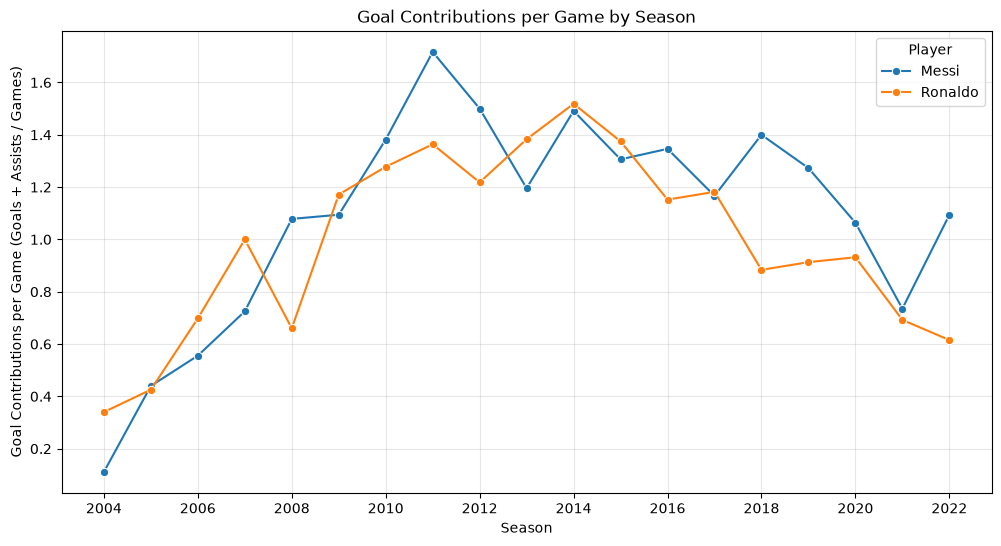

In [64]:
import matplotlib.ticker as ticker
plt.figure(figsize=(12, 6))
sns.lineplot(data=long_stats, x='Season_Start', y='GC_per_Game', hue='Player', marker='o')
plt.title('Goal Contributions per Game by Season')
plt.xlabel('Season')
plt.ylabel('Goal Contributions per Game (Goals + Assists / Games)')
plt.legend(title='Player')
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.show()

In [65]:
# Check if Data is statistically significant 

In [69]:
paired = long_stats.pivot(index='Season_Start', columns='Player', values='GC_per_Game')
paired

Player,Messi,Ronaldo
Season_Start,,
2004,0.111111,0.340000
2005,0.440000,0.425532
2006,0.555556,0.698113
2007,0.725000,1.000000
2008,1.078431,0.660377
2009,1.094340,1.171429
2010,1.381818,1.277778
2011,1.716667,1.363636
2012,1.500000,1.218182


In [88]:
# t-statistic: measures the size of the gap between Messi and Ronaldo's averages
# (bigger t = the gap looks more like a real pattern, less like random noise)

# p-value: the probability of seeing a gap this large just by chance, if Messi and Ronaldo were actually equally effective
# (below 0.05 = considered "statistically significant"; ours is 0.097, so not significant)

In [73]:

from scipy import stats

t_stat, p_value = stats.ttest_rel(paired['Messi'], paired['Ronaldo'])
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 1.752
P-value: 0.0968


In [78]:
mean_diff = (paired['Messi'] - paired['Ronaldo']).mean()
print(f"Average difference (Messi - Ronaldo): {mean_diff:.3f} GC per game")

Average difference (Messi - Ronaldo): 0.099 GC per game


In [79]:
#Seeing the data in SQL

In [80]:
#Creates database file using SQL Lite
# Takes the information from the pandas data frame and turn it into an SQL table

In [81]:
conn = sqlite3.connect('soccer_stats.db')
long_stats.to_sql('season_stats', conn, if_exists='replace', index=False)

38

In [82]:
#Get each player's average effectiveness (Goal contribution average to compare

In [83]:
query = """
SELECT Player, ROUND(AVG(GC_per_Game), 3) as avg_effectiveness
FROM season_stats
GROUP BY Player
"""
pd.read_sql(query, conn)

,Player,avg_effectiveness
0,Messi,1.088
1,Ronaldo,0.990


In [84]:
#Rank each players season from best to worst

In [85]:
query = """
SELECT Player, Season_Start, GC_per_Game,
       RANK() OVER (PARTITION BY Player ORDER BY GC_per_Game DESC) as season_rank
FROM season_stats
ORDER BY Player, season_rank
"""
pd.read_sql(query, conn)

,Player,Season_Start,GC_per_Game,season_rank
0,Messi,2011,1.716667,1
1,Messi,2012,1.500000,2
2,Messi,2014,1.491228,3
3,Messi,2018,1.400000,4
4,Messi,2010,1.381818,5
5,Messi,2016,1.346154,6
6,Messi,2015,1.306122,7
7,Messi,2019,1.272727,8
8,Messi,2013,1.195652,9
9,Messi,2017,1.166667,10


In [ ]:
# Checking hoe many elite seasons each player had above a 1.3 goal Contribution ratio

In [86]:
query = """
SELECT Player, COUNT(*) as elite_seasons
FROM season_stats
WHERE GC_per_Game > 1.3
GROUP BY Player
"""
pd.read_sql(query, conn)

,Player,elite_seasons
0,Messi,7
1,Ronaldo,4
